(https://github.com/sihsieh65-tech/cs82a-portfolio/tree/main/Module5)

Import libraries and data set

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df= pd.read_csv("custdata.tsv", sep="\t")
df

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
0,2068,F,NaN,11300,Married,True,Homeowner free and clear,False,2.0,49.0,Michigan
1,2073,F,NaN,0,Married,True,Rented,True,3.0,40.0,Florida
2,2848,M,True,4500,Never Married,False,Rented,True,3.0,22.0,Georgia
3,5641,M,True,20000,Never Married,False,Occupied with no rent,False,0.0,22.0,New Mexico
4,6369,F,True,12000,Never Married,True,Rented,True,1.0,31.0,Florida
...,...,...,...,...,...,...,...,...,...,...,...
995,1411132,F,False,46000,Divorced/Separated,True,Rented,True,1.0,56.0,Florida
996,1411860,F,NaN,5400,Widowed,True,NaN,NaN,NaN,89.0,Pennsylvania
997,1412161,M,True,38500,Married,True,Rented,True,1.0,29.0,Georgia
998,1412971,M,NaN,43400,Married,True,Homeowner free and clear,False,1.0,88.0,Ohio


Ran a quick diagnostic to see what state the data is in. 

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   custid        1000 non-null   int64  
 1   sex           1000 non-null   str    
 2   is.employed   672 non-null    object 
 3   income        1000 non-null   int64  
 4   marital.stat  1000 non-null   str    
 5   health.ins    1000 non-null   bool   
 6   housing.type  944 non-null    str    
 7   recent.move   944 non-null    object 
 8   num.vehicles  944 non-null    float64
 9   age           1000 non-null   float64
 10  state.of.res  1000 non-null   str    
dtypes: bool(1), float64(2), int64(2), object(2), str(4)
memory usage: 79.2+ KB


I created a heatmap based on the table data before any data cleaning. 

<Axes: >

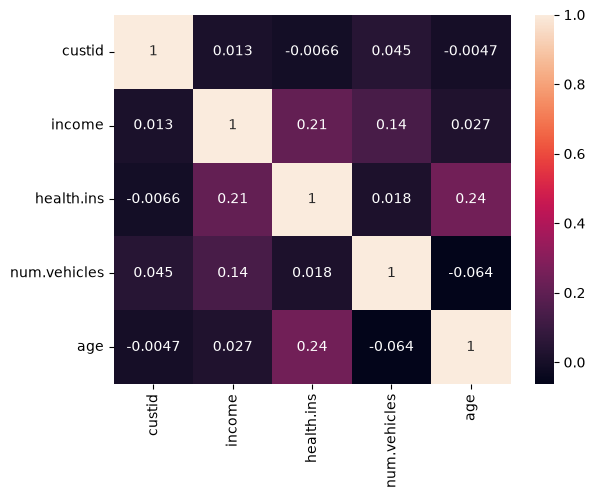

In [3]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

I ran a secondary diagnostic to see if there was anything problematic in the dataset. Based on the result I can see a number of problems.

1) There are na values in the housing.type column that need to be removed
2) There are negative income values
3) There is an impossible minimum age of zero
4) There are a number of people with ages reported to be over 100 which is highly unlikely. 

In [4]:
df.isna().sum()

custid            0
sex               0
is.employed     328
income            0
marital.stat      0
health.ins        0
housing.type     56
recent.move      56
num.vehicles     56
age               0
state.of.res      0
dtype: int64

In [5]:
df.describe()

,custid,income,num.vehicles,age
count,1.000000e+03,1000.000000,944.000000,1000.000000
mean,6.984997e+05,53504.771000,1.916314,51.699815
std,4.135083e+05,65478.065729,1.101618,18.863433
min,2.068000e+03,-8700.000000,0.000000,0.000000
25%,3.456668e+05,14600.000000,1.000000,38.000000
50%,6.934030e+05,35000.000000,2.000000,50.000000
75%,1.044606e+06,67000.000000,2.000000,64.000000
max,1.414286e+06,615000.000000,6.000000,146.680197


Dropped all NA for housing type. This removed 56 rows.

In [6]:
df_cleaned = df.dropna(subset=['housing.type'])
df_cleaned

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
0,2068,F,NaN,11300,Married,True,Homeowner free and clear,False,2.0,49.0,Michigan
1,2073,F,NaN,0,Married,True,Rented,True,3.0,40.0,Florida
2,2848,M,True,4500,Never Married,False,Rented,True,3.0,22.0,Georgia
3,5641,M,True,20000,Never Married,False,Occupied with no rent,False,0.0,22.0,New Mexico
4,6369,F,True,12000,Never Married,True,Rented,True,1.0,31.0,Florida
...,...,...,...,...,...,...,...,...,...,...,...
994,1409249,M,NaN,36200,Married,True,Homeowner free and clear,False,5.0,73.0,New York
995,1411132,F,False,46000,Divorced/Separated,True,Rented,True,1.0,56.0,Florida
997,1412161,M,True,38500,Married,True,Rented,True,1.0,29.0,Georgia
998,1412971,M,NaN,43400,Married,True,Homeowner free and clear,False,1.0,88.0,Ohio


I converted all negative income values to positive values. I am assuming there was a data input error. 

In [7]:
df_cleaned['income'] = df_cleaned['income'].abs()
df_cleaned

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
0,2068,F,NaN,11300,Married,True,Homeowner free and clear,False,2.0,49.0,Michigan
1,2073,F,NaN,0,Married,True,Rented,True,3.0,40.0,Florida
2,2848,M,True,4500,Never Married,False,Rented,True,3.0,22.0,Georgia
3,5641,M,True,20000,Never Married,False,Occupied with no rent,False,0.0,22.0,New Mexico
4,6369,F,True,12000,Never Married,True,Rented,True,1.0,31.0,Florida
...,...,...,...,...,...,...,...,...,...,...,...
994,1409249,M,NaN,36200,Married,True,Homeowner free and clear,False,5.0,73.0,New York
995,1411132,F,False,46000,Divorced/Separated,True,Rented,True,1.0,56.0,Florida
997,1412161,M,True,38500,Married,True,Rented,True,1.0,29.0,Georgia
998,1412971,M,NaN,43400,Married,True,Homeowner free and clear,False,1.0,88.0,Ohio


In [8]:
df_cleaned.describe()

,custid,income,num.vehicles,age
count,9.440000e+02,944.000000,944.000000,944.000000
mean,6.987750e+05,56329.026483,1.916314,51.933066
std,4.140340e+05,66288.002076,1.101618,18.437944
min,2.068000e+03,0.000000,0.000000,0.000000
25%,3.430412e+05,17000.000000,1.000000,39.000000
50%,7.059435e+05,37200.000000,2.000000,50.000000
75%,1.044606e+06,70000.000000,2.000000,64.000000
max,1.414286e+06,615000.000000,6.000000,146.680197


I dropped row where the age was recorded as lower than the legal driving age of 16 and less than 100. This removed 11 rows. 

In [9]:
df_cleaned2 = df_cleaned[(df_cleaned["age"] > 15) & (df_cleaned["age"] < 100)]
df_cleaned2

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
0,2068,F,NaN,11300,Married,True,Homeowner free and clear,False,2.0,49.0,Michigan
1,2073,F,NaN,0,Married,True,Rented,True,3.0,40.0,Florida
2,2848,M,True,4500,Never Married,False,Rented,True,3.0,22.0,Georgia
3,5641,M,True,20000,Never Married,False,Occupied with no rent,False,0.0,22.0,New Mexico
4,6369,F,True,12000,Never Married,True,Rented,True,1.0,31.0,Florida
...,...,...,...,...,...,...,...,...,...,...,...
994,1409249,M,NaN,36200,Married,True,Homeowner free and clear,False,5.0,73.0,New York
995,1411132,F,False,46000,Divorced/Separated,True,Rented,True,1.0,56.0,Florida
997,1412161,M,True,38500,Married,True,Rented,True,1.0,29.0,Georgia
998,1412971,M,NaN,43400,Married,True,Homeowner free and clear,False,1.0,88.0,Ohio


In [10]:
df_cleaned2.describe()

,custid,income,num.vehicles,age
count,9.330000e+02,933.000000,933.000000,933.000000
mean,6.962752e+05,55898.661308,1.915327,51.431940
std,4.136914e+05,66022.768668,1.103210,16.796782
min,2.068000e+03,0.000000,0.000000,19.000000
25%,3.415070e+05,17000.000000,1.000000,39.000000
50%,7.023480e+05,37000.000000,2.000000,50.000000
75%,1.042303e+06,70000.000000,2.000000,63.000000
max,1.414286e+06,615000.000000,6.000000,93.000000


I re-ran the heatmap with the cleaned up data. 

<Axes: >

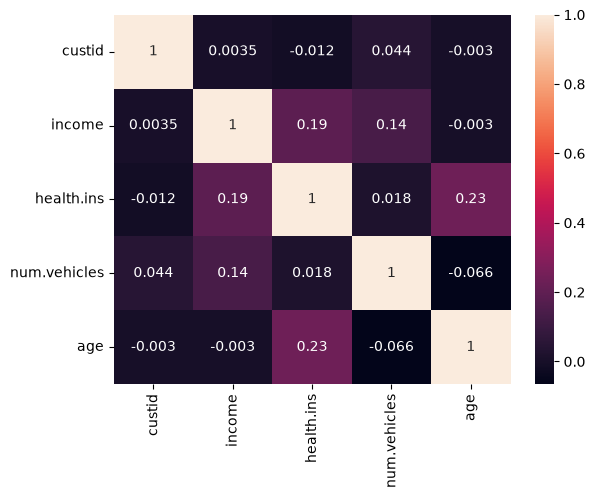

In [11]:
sns.heatmap(df_cleaned2.corr(numeric_only=True), annot=True)

I plotted a few of the scatter plots just to visualize the correlations in the heatmap.

Text(0.5, 1.0, 'No people without health insurance were over 70 years old')

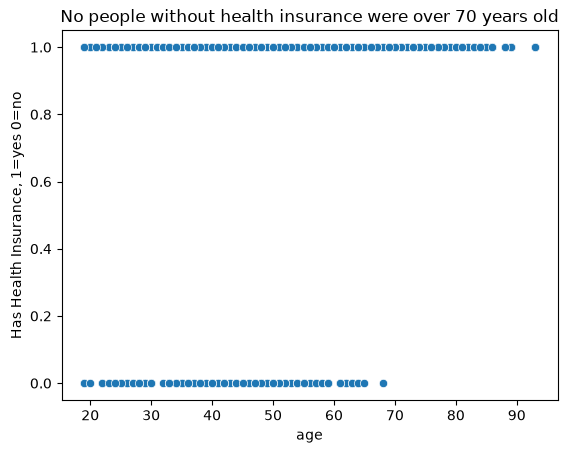

In [12]:
sns.scatterplot(data=df_cleaned2, x="age", y="health.ins")
plt.ylabel("Has Health Insurance, 1=yes 0=no")
plt.title("No people without health insurance were over 70 years old")

<Axes: xlabel='age', ylabel='income'>

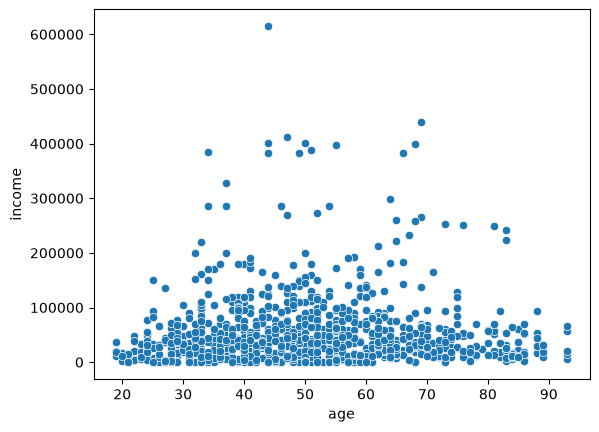

In [13]:
sns.scatterplot(data=df_cleaned2, x="age", y="income")

<Axes: xlabel='num.vehicles', ylabel='income'>

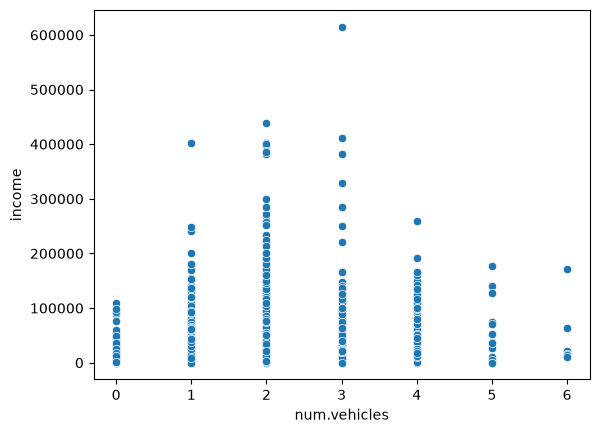

In [14]:
sns.scatterplot(data=df_cleaned2, x="num.vehicles", y="income")

Overall, looking at the correlation in the heatmap it appears much of the data does not correlate well. The highest correlation was 0.21 between age and health insurance. While not strictly correlated I did notice something interesting when plotting the data in a scatterplot. There were no people without health insurance that past the age of 70. Meanwhile, among the poplation with health insurance there was a notable number of people ages 70 and up. 